# 相關套件

## 載入雲端

In [1]:

#####################################################################################################

import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

#####################################################################################################


Mounted at /content/drive


## 安裝套件

In [2]:

#####################################################################################################

!pip install cleanvision
!pip install cleanvision

#####################################################################################################


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 58.7 MB/s eta 0:00:00


## 載入套件

In [3]:

#####################################################################################################

import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from cleanvision import Imagelab
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random
import albumentations as A
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
from functools import partial
from PIL import Image

#####################################################################################################


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 資料集複製

In [ ]:

# #####################################################################################################

# # 定義來源和目標資料夾路徑
# source_folder = "/content/drive/MyDrive/數據科學實務與創新/期末報告/"
# destination_folder = "/content/drive/MyDrive/數據科學_期末"

# # 複製來源資料夾到目標資料夾
# shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

# print("資料夾複製完成！")

# #####################################################################################################


# 擴增資料


## "外部資料"解壓縮

In [34]:

# ######################################################################################################

# # 設定解壓縮目標目錄
# target_dir = '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset'

# # 創建目標目錄（如果不存在）
# if not os.path.exists(target_dir):
#     os.makedirs(target_dir)
#     print(f"資料夾 {target_dir} 已建立。")

# # 解壓縮 zip 檔案至目標目錄
# try:
#     with zipfile.ZipFile('/content/drive/MyDrive/數據科學_期末/Roman Numerals Datase.zip', 'r') as zip_ref:
#         zip_ref.extractall(target_dir)
#     print("解壓縮成功！")
# except zipfile.BadZipFile:
#     print("錯誤：無效的 ZIP 檔案！")
# except FileNotFoundError:
#     print("錯誤：檔案未找到！")

# ######################################################################################################


資料夾 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset 已建立。
解壓縮成功！


## 重新命名

In [ ]:

# ######################################################################################################

# import os

# # 定義路徑
# ADD_Data = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Combined Handwritten Roman Numerals Dataset/train"
# categories = ["i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x"]

# # 重新命名檔案
# for category in categories:
#     category_path = os.path.join(ADD_Data, category)
#     if os.path.exists(category_path):
#         for file in os.listdir(category_path):
#             old_file_path = os.path.join(category_path, file)
#             if "_" in file:
#                 name_parts = file.split("_", 1)  # 分割檔名
#                 new_file_name = f"{name_parts[0]}_ADD_{name_parts[1]}"
#                 new_file_path = os.path.join(category_path, new_file_name)
#                 os.rename(old_file_path, new_file_path)
#                 print(f"重新命名: {old_file_path} -> {new_file_path}")

# ######################################################################################################


## 合併資料

In [ ]:

# # ######################################################################################################

# import os
# import os
# import shutil

# # 定義路徑
# OR_Data = "/content/drive/MyDrive/數據科學_期末/practical-innovative-analytics-data-science-2024/training_data/train"
# ADD_Data = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Combined Handwritten Roman Numerals Dataset/train"
# Merge_data_path = "/content/drive/MyDrive/數據科學_期末/Merge_data"

# categories = ["i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x"]

# # 確保目標資料夾存在
# os.makedirs(Merge_data_path, exist_ok=True)

# # 合併資料
# for category in categories:
#     # 定義每個類別的來源和目標路徑
#     OR_category_path = os.path.join(OR_Data, category)
#     ADD_category_path = os.path.join(ADD_Data, category)
#     Merge_category_path = os.path.join(Merge_data_path, category)

#     # 確保目標類別資料夾存在
#     os.makedirs(Merge_category_path, exist_ok=True)

#     # 複製來自 OR_Data 的資料
#     if os.path.exists(OR_category_path):
#         for file in os.listdir(OR_category_path):
#             src_file = os.path.join(OR_category_path, file)
#             dest_file = os.path.join(Merge_category_path, file)
#             shutil.copy(src_file, dest_file)

#     # 複製來自 ADD_Data 的資料
#     if os.path.exists(ADD_category_path):
#         for file in os.listdir(ADD_category_path):
#             src_file = os.path.join(ADD_category_path, file)
#             dest_file = os.path.join(Merge_category_path, file)
#             shutil.copy(src_file, dest_file)

# print(f"資料已成功合併到 {Merge_data_path}")



# # ######################################################################################################


## 圖片資料轉換(轉黑白)

In [ ]:
# import cv2
# import os

# # 資料集路徑
# input_folder = '/content/drive/MyDrive/數據科學_期末/Merge_data'
# output_folder = '/content/drive/MyDrive/數據科學_期末/Merge_data/black_white'

# # 類別列表
# categories = ["i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x"]

# # 確保輸出資料夾存在
# os.makedirs(output_folder, exist_ok=True)

# # 讀取每個類別的資料夾並轉換圖像
# for category in categories:
#     category_input_folder = os.path.join(input_folder, category)
#     category_output_folder = os.path.join(output_folder, category)

#     # 確保類別輸出資料夾存在
#     os.makedirs(category_output_folder, exist_ok=True)

#     # 讀取並轉換圖像
#     if os.path.exists(category_input_folder):
#         for filename in os.listdir(category_input_folder):
#             if filename.endswith('.jpg') or filename.endswith('.png'):  # 檢查是否為圖像檔案
#                 img_path = os.path.join(category_input_folder, filename)
#                 img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # 讀取為灰階圖像
#                 output_path = os.path.join(category_output_folder, filename)  # 儲存到對應類別資料夾
#                 cv2.imwrite(output_path, img)  # 儲存轉換後的圖像

# print("所有圖像已根據類別轉換為黑白，儲存至：", output_folder)

## 檢查是否存在

In [ ]:
# import os

# directory_path = output_folder

# # 檢查目錄是否存在
# if os.path.exists(directory_path):
#     print(f"Directory {directory_path} exists. Contents:")
#     for file_name in os.listdir(directory_path):
#         print(file_name)
# else:
#     print(f"Directory {directory_path} does not exist.")


# 資料預處理(Clean_vision)

## 當前目錄


In [ ]:

# #####################################################################################################

# # 取得目前工作目錄
# current_directory = os.getcwd()

# print("目前所在的資料夾位置是：", current_directory)

# #####################################################################################################


目前所在的資料夾位置是： /content


## 位置參數設置

In [35]:

# #####################################################################################################

# # 設定資料路徑與參數

# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# user_data = directory / "train"
# train_data = user_data
# # train_dir = train_data
# out_dir = directory / "Cleanvision_merge_data"

# # 創建目標目錄（如果不存在）
# if not os.path.exists(out_dir):
#     os.makedirs(out_dir)
#     print(f"資料夾 {out_dir} 已建立。")

# #####################################################################################################


資料夾 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data 已建立。


In [36]:

# #####################################################################################################

# if not os.path.exists(out_dir):
#     os.makedirs(out_dir)
#     print(f"資料夾 {out_dir} 已建立。")
# else:
#     print(f"資料夾 {out_dir} 已存在。")

# #####################################################################################################


資料夾 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data 已存在。


# 創建原始(ORtrain)資料副本

In [82]:
# import shutil
# from pathlib import Path

# # 原始資料路徑
# original_dir = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/train")
# # 目標資料夾路徑
# target_dir = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain")

# # 檢查目標資料夾是否存在
# if not target_dir.exists():
#     shutil.copytree(original_dir, target_dir)
#     print(f"資料夾已從 {original_dir} 複製到 {target_dir} 並重新命名為 ORtrain。")
# else:
#     print(f"目標資料夾 {target_dir} 已存在，未進行複製。")


資料夾已從 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/train 複製到 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain 並重新命名為 ORtrain。


In [83]:

# #####################################################################################################

# if not os.path.exists(target_dir):
#     os.makedirs(target_dir)
#     print(f"資料夾 {target_dir} 已建立。")
# else:
#     print(f"資料夾 {target_dir} 已存在。")

# #####################################################################################################


資料夾 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain 已存在。


In [46]:
import os
import shutil

# 定義來源資料夾和目標資料夾
source_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain"
target_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images"

# 確保目標資料夾存在
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 遍歷來源資料夾
for root, dirs, files in os.walk(source_dir):
    for file_name in files:
        if file_name.endswith(".png"):  # 僅處理 .png 檔案
            source_file = os.path.join(root, file_name)
            target_file = os.path.join(target_dir, file_name)
            try:
                shutil.copy2(source_file, target_file)
                print(f"已成功複製檔案: {source_file} 至 {target_file}")
            except Exception as e:
                print(f"無法複製檔案: {source_file}, 錯誤: {e}")

print(f"所有 .png 檔案已複製至目標資料夾: {target_dir}")


串流輸出內容已截斷至最後 5000 行。
無法複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_159.png, 錯誤: '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_159.png' and '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_159.png' are the same file
無法複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_168.png, 錯誤: '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_168.png' and '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_168.png' are the same file
無法複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_160.png, 錯誤: '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_160.png' and '/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_ADD_160.png' are the same file
無法複製檔案: /content/drive/MyDrive/數據科學_期末/Roma

# 查看未清理(ORtrain)報表

In [84]:

#####################################################################################################

ORtrain_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain")

imagelab = Imagelab(data_path=ORtrain_path)
issues = imagelab.find_issues(verbose=False)

# imagelab.report(max_prevalence=1.00)

display(imagelab.issue_summary)
imagelab_df = imagelab.issues
display(imagelab_df)

#####################################################################################################


Reading images from /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain


  0%|          | 0/7910 [00:00<?, ?it/s]

  0%|          | 0/7910 [00:00<?, ?it/s]

,issue_type,num_images
0,grayscale,7910
1,low_information,5701
2,light,1313
3,odd_size,822
4,near_duplicates,88
5,odd_aspect_ratio,8
6,dark,1
7,blurry,1
8,exact_duplicates,0


,odd_size_score,is_odd_size_issue,odd_aspect_ratio_score,is_odd_aspect_ratio_issue,low_information_score,is_low_information_issue,light_score,is_light_issue,grayscale_score,is_grayscale_issue,dark_score,is_dark_issue,blurry_score,is_blurry_issue,exact_duplicates_score,is_exact_duplicates_issue,near_duplicates_score,is_near_duplicates_issue
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/i/i_0.png,0.951660,False,0.954545,False,0.036344,True,0.749020,False,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/i/i_1.png,0.944283,False,0.804348,False,0.032163,True,0.749020,False,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/i/i_10.png,0.949631,False,0.979339,False,0.035782,True,0.749020,False,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/i/i_100.png,0.999651,False,0.715026,False,0.024825,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/i/i_101.png,0.999152,False,1.000000,False,0.052214,True,0.749020,False,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/x/x_ADD_455.png,0.926331,False,0.892857,False,0.362956,False,0.396078,False,0,True,0.792157,False,0.890286,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/x/x_ADD_456.png,0.989105,False,0.537313,False,0.555867,False,0.678431,False,0,True,0.737255,False,0.728969,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/x/x_ADD_457.png,0.921727,False,0.957447,False,0.423046,False,0.505882,False,0,True,0.815686,False,0.795403,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/x/x_ADD_458.png,0.913421,False,0.970588,False,0.416032,False,0.584314,False,0,True,0.678431,False,0.640321,False,1.0,False,1.0,False


In [90]:

####################################################################################################

# 確認目標目錄存在，否則創建
output_dir = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain_Cleanvision_Report")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"資料夾 {output_dir} 已建立。")

# 假設 imagelab_df 是一個 pandas DataFrame
imagelab_df.to_csv(output_dir / "imagelab_df.csv", index=False)
print("imagelab_df 資料集已成功輸出至目標目錄。")

#####################################################################################################


imagelab_df 資料集已成功輸出至目標目錄。


In [89]:

#####################################################################################################

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"資料夾 {output_dir} 已建立。")
else:
    print(f"資料夾 {output_dir} 已存在。")

#####################################################################################################


資料夾 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain_Cleanvision_Report 已存在。


## 刪除不適資料(Cleanvision_merge_data)


In [77]:

# #####################################################################################################

# # 定義原始資料夾與目標資料夾
# ORtrain_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain")
# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 確認目標資料夾是否存在，若無則建立
# if not Cleanvision_merge_data_path.exists():
#     Cleanvision_merge_data_path.mkdir(parents=True)
#     print(f"已建立資料夾: {Cleanvision_merge_data_path}")

# # 複製原始資料至目標資料夾
# for file in ORtrain_path.rglob("*"):  # 遍歷原始資料夾中的所有檔案
#     if file.is_file():  # 確保只處理檔案
#         dest_path = Cleanvision_merge_data_path / file.relative_to(ORtrain_path)  # 保持原始結構
#         dest_path.parent.mkdir(parents=True, exist_ok=True)  # 建立子資料夾（若需要）
#         shutil.copy2(file, dest_path)  # 複製檔案，保留檔案的原始 metadata
#         print(f"已複製: {file} 至 {dest_path}")

# #####################################################################################################


# #####################################################################################################

# # 資料讀取
# # imagelab = pd.read_csv("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain_Cleanvision_Report/imagelab_df.csv")
# ORtrain_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain")
# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 篩選各類問題影像
# low_information_images = imagelab.issues[imagelab.issues["is_low_information_issue"]].sort_values(by=["low_information_score"])
# low_information_files = low_information_images.index.tolist()

# # 計算 low_information_score 的分位數，後 60%  # 上方30%，下方0.7
# threshold = low_information_images['low_information_score'].quantile(0.4)

# # 選出需要刪除的影像檔案
# files_to_remove = low_information_images[low_information_images['low_information_score'] > threshold].index.tolist()

# # 刪除 Cleanvision_merge_data_path 中的對應影像檔案
# for file in files_to_remove:
#     clean_path = Cleanvision_merge_data_path / file
#     if clean_path.exists():  # 確保檔案存在
#         clean_path.unlink()  # 刪除檔案
#         print(f"已刪除: {clean_path}")
#     else:
#         print(f"檔案不存在，無法刪除: {clean_path}")

# #####################################################################################################



已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_79.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_198.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_179.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/ii/ii_103.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_189.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/iii/iii_ADD_018.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/vi/vi_188.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/iv/iv_196.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/ix/ix_299.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/ix/ix_117.png
已刪除: /content/drive/MyDrive/數據科學_期末/Roman N

In [91]:
# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# imagelab = Imagelab(data_path=Cleanvision_merge_data_path)
# issues = imagelab.find_issues(verbose=False)

# # imagelab.report(max_prevalence=1.00)

# display(imagelab.issue_summary)
# imagelab_df = imagelab.issues
# display(imagelab_df)

# #####################################################################################################

Reading images from /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data


  0%|          | 0/3350 [00:00<?, ?it/s]

  0%|          | 0/3350 [00:00<?, ?it/s]

,issue_type,num_images
0,grayscale,3350
1,low_information,1141
2,light,1050
3,odd_size,72
4,odd_aspect_ratio,7
5,near_duplicates,4
6,dark,1
7,blurry,1
8,exact_duplicates,0


,odd_size_score,is_odd_size_issue,odd_aspect_ratio_score,is_odd_aspect_ratio_issue,low_information_score,is_low_information_issue,light_score,is_light_issue,grayscale_score,is_grayscale_issue,dark_score,is_dark_issue,blurry_score,is_blurry_issue,exact_duplicates_score,is_exact_duplicates_issue,near_duplicates_score,is_near_duplicates_issue
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_100.png,0.992803,False,0.715026,False,0.024825,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_102.png,0.926313,False,0.659091,False,0.030650,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_104.png,0.939840,False,0.937500,False,0.020994,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_106.png,0.954693,False,0.787500,False,0.026416,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/i/i_107.png,0.926313,False,0.659091,False,0.030624,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_ADD_455.png,0.922766,False,0.892857,False,0.362956,False,0.396078,False,0,True,0.792157,False,0.890286,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_ADD_456.png,0.995053,False,0.537313,False,0.555867,False,0.678431,False,0,True,0.737255,False,0.728969,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_ADD_457.png,0.917464,False,0.957447,False,0.423046,False,0.505882,False,0,True,0.815686,False,0.795403,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data/x/x_ADD_458.png,0.907900,False,0.970588,False,0.416032,False,0.584314,False,0,True,0.678431,False,0.640321,False,1.0,False,1.0,False


# 建立模型CNN

## i

In [105]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "i"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 842 images belonging to 2 classes.
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 371ms/step - accuracy: 0.6493 - loss: 1.9707
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.8318 - loss: 0.4280
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 427ms/step - accuracy: 0.8991 - loss: 0.2858
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 436ms/step - accuracy: 0.9188 - loss: 0.2108
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 363ms/step - accuracy: 0.9668 - loss: 0.1001


In [104]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

## ii

In [106]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "ii"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 718 images belonging to 2 classes.
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 365ms/step - accuracy: 0.6303 - loss: 1.6362
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.8209 - loss: 0.7659
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 413ms/step - accuracy: 0.8704 - loss: 0.3954
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - accuracy: 0.8990 - loss: 0.3129
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 451ms/step - accuracy: 0.9184 - loss: 0.2423


In [107]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

## iii

In [98]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "iii"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 10

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 712 images belonging to 2 classes.
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 403ms/step - accuracy: 0.6027 - loss: 1.5586
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 456ms/step - accuracy: 0.7777 - loss: 0.8647
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.8946 - loss: 0.4224
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step - accuracy: 0.9350 - loss: 0.2710
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step - accuracy: 0.9220 - loss: 0.1741
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 330ms/step - accuracy: 0.9770 - loss: 0.0976
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 429ms/step - accuracy: 0.9719 - loss: 0.0805
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 348ms/step - accuracy: 0.9758 - loss: 0.0644
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 376ms/step - accuracy: 0.9899 - loss: 0.0356
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.9815 - loss: 0.0597


In [99]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

## iv

In [6]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "iv"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 708 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6240 - loss: 1.5092
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 385ms/step - accuracy: 0.8635 - loss: 0.4575
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.9215 - loss: 0.2545
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.9518 - loss: 0.1239
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - accuracy: 0.9749 - loss: 0.0703


In [7]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━

## ix

In [8]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "ix"  # 指定要訓練的類別
# negative_class = "v"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 657 images belonging to 2 classes.
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6409 - loss: 1.8552
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 493ms/step - accuracy: 0.8193 - loss: 0.5342
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - accuracy: 0.8786 - loss: 0.3558
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 355ms/step - accuracy: 0.9388 - loss: 0.1719
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 462ms/step - accuracy: 0.9634 - loss: 0.1100


In [9]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

## v

In [18]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "v"  # 指定要訓練的類別
# negative_class = "ix"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 10

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 657 images belonging to 2 classes.
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 381ms/step - accuracy: 0.6656 - loss: 1.5050
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.7994 - loss: 0.7361
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step - accuracy: 0.8949 - loss: 0.2928
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 359ms/step - accuracy: 0.9500 - loss: 0.1467
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.9576 - loss: 0.1290
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step - accuracy: 0.9788 - loss: 0.0573
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.9882 - loss: 0.0494
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 319ms/step - accuracy: 0.9973 - loss: 0.0151
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 370ms/step - accuracy: 0.9970 - loss: 0.0181
Epoch 10/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - accuracy: 0.9924 - loss: 0.0203


In [19]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

## vi

In [20]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "vi"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 703 images belonging to 2 classes.
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 482ms/step - accuracy: 0.6114 - loss: 1.8909
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 437ms/step - accuracy: 0.8247 - loss: 0.5339
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.8838 - loss: 0.2891
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 547ms/step - accuracy: 0.9168 - loss: 0.1992
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.9757 - loss: 0.0788


In [21]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

## vii

In [22]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "vii"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 676 images belonging to 2 classes.
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 403ms/step - accuracy: 0.6744 - loss: 1.1827
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.9036 - loss: 0.3332
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 511ms/step - accuracy: 0.9399 - loss: 0.2445
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 387ms/step - accuracy: 0.9710 - loss: 0.1292
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 497ms/step - accuracy: 0.9695 - loss: 0.0668


In [23]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━

## viii

In [24]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "viii"  # 指定要訓練的類別
# negative_class = "x"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 10

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 776 images belonging to 2 classes.
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8012 - loss: 1.0481
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.8908 - loss: 0.5281
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 335ms/step - accuracy: 0.9570 - loss: 0.1571
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.9747 - loss: 0.1312
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 381ms/step - accuracy: 0.9685 - loss: 0.1205
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 303ms/step - accuracy: 0.9562 - loss: 0.1162
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 359ms/step - accuracy: 0.9806 - loss: 0.0717
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 393ms/step - accuracy: 0.9967 - loss: 0.0165
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 0.9951 - loss: 0.0171
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 393ms/step - accuracy: 0.9960 - loss: 0.0118


In [25]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━

## x

In [26]:
# from tensorflow.keras.layers import BatchNormalization



# target_class = "x"  # 指定要訓練的類別
# negative_class = "viii"  # 指定負樣本類別

# #####################################################################################################

# Cleanvision_merge_data_path = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Cleanvision_merge_data")

# # 設定資料夾
# directory = Path("/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset")
# train_base_dir = Cleanvision_merge_data_path
# out_dir = directory / "Outcome"




# # 檢查目標路徑
# train_dir = os.path.join(train_base_dir, target_class)
# negative_dir_path = os.path.join(train_base_dir, negative_class)

# if not os.path.exists(train_dir):
#     raise ValueError(f"目標類別資料夾不存在: {train_dir}")
# if not os.path.exists(negative_dir_path):
#     raise ValueError(f"負樣本類別資料夾不存在: {negative_dir_path}")

# # 圖片大小與參數
# image_size = (64, 64)
# batch_size = 32
# epochs = 5

# # 清理暫存資料夾（如果已存在）
# temp_train_dir = "/tmp/train_data"
# if os.path.exists(temp_train_dir):
#     shutil.rmtree(temp_train_dir)  # 刪除暫存目錄及其內容

# # 重新建立正負樣本資料夾
# os.makedirs(temp_train_dir, exist_ok=True)
# positive_dir = os.path.join(temp_train_dir, "positive")
# negative_dir = os.path.join(temp_train_dir, "negative")
# os.makedirs(positive_dir, exist_ok=True)
# os.makedirs(negative_dir, exist_ok=True)

# # 複製正樣本
# for file in os.listdir(train_dir):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(train_dir, file)
#         dst = os.path.join(positive_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 複製負樣本
# for file in os.listdir(negative_dir_path):
#     if file.endswith(('png', 'jpg', 'jpeg')):
#         src = os.path.join(negative_dir_path, file)
#         dst = os.path.join(negative_dir, file)
#         if not os.path.exists(dst):  # 檢查目標文件是否存在
#             os.symlink(src, dst)

# # 資料增強器
# datagen = ImageDataGenerator(rescale=1.0/255.0)

# # 載入正負樣本資料
# train_generator = datagen.flow_from_directory(
#     directory=temp_train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     shuffle=True
# )

# # CNN 模型
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


# # model = Sequential([
# #     # Input(shape=(64, 64, 3)),  # 第一層：指定輸入形狀, match the image_size
# #     Conv2D(16, (3, 3), activation='relu'),  # 輸入層，128x128的灰階圖片
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(32, (3, 3), activation='relu'),  # 第二層卷積層
# #     MaxPooling2D((2, 2)),  # 最大池化層
# #     Conv2D(64, (3, 3), activation='relu'),  # 第三層卷積層
# #     Flatten(),  # 展平層
# #     # The input to the Dense layer should be 9216 to match the flattened output
# #     Dense(9216, activation='relu'),  # 全連接層
# #     Dropout(0.5),  # Dropout層，防止過擬合
# #     Dense(1, activation='softmax')  # 輸出層，根據類別數量調整
# # ])


# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# # 模型訓練
# model.fit(train_generator, epochs=epochs)

# # 保存模型
# model_path = os.path.join(out_dir, f"cnn_model_{target_class}.h5")
# os.makedirs(out_dir, exist_ok=True)
# model.save(model_path)

# #####################################################################################################


Found 776 images belonging to 2 classes.
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 346ms/step - accuracy: 0.7663 - loss: 1.2012
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 398ms/step - accuracy: 0.9222 - loss: 0.3121
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 332ms/step - accuracy: 0.9576 - loss: 0.1322
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 391ms/step - accuracy: 0.9758 - loss: 0.1093
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 325ms/step - accuracy: 0.9699 - loss: 0.0874


In [27]:

# #####################################################################################################

# # 預測並生成信心矩陣
# image_files = [f for f in os.listdir(train_dir) if f.endswith(('png', 'jpg', 'jpeg'))]
# confidence_data = []

# for image_file in image_files:
#     img_path = os.path.join(train_dir, image_file)
#     img = load_img(img_path, target_size=image_size)
#     img_array = img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # 預測概率
#     confidence = model.predict(img_array)[0][0]
#     confidence_data.append({'id': image_file, 'Confidence': confidence})

# # 儲存信心矩陣為 CSV
# confidence_df = pd.DataFrame(confidence_data)
# confidence_csv_path = os.path.join(out_dir, f"confidence_matrix_{target_class}.csv")
# confidence_df.to_csv(confidence_csv_path, index=False)

# print(f"信心矩陣已保存至: {confidence_csv_path}")

# #####################################################################################################


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

# 對應資料集分類

In [31]:
import os
import shutil

# 定義來源資料夾和目標根資料夾
source_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome"
target_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class"

# 定義目標類別
target_classes = {'i', 'ii', 'iii', 'iv', 'ix', 'v', 'vi', 'vii', 'viii', 'x'}

# 確保目標類別的資料夾存在
for target_class in target_classes:
    target_class_dir = os.path.join(target_root_dir, target_class)
    if not os.path.exists(target_class_dir):
        os.makedirs(target_class_dir)

# 分類並複製檔案
for file_name in os.listdir(source_dir):
    source_file = os.path.join(source_dir, file_name)

    # 確保只處理檔案，忽略資料夾或不支援的檔案類型
    if os.path.isfile(source_file) and not file_name.endswith('.gsheet'):
        # 根據檔名中的類別進行匹配
        for target_class in target_classes:
            if f"_{target_class}." in file_name:
                target_class_dir = os.path.join(target_root_dir, target_class)
                target_file = os.path.join(target_class_dir, file_name)
                try:
                    # 顯示複製的過程
                    print(f"正在複製檔案: {source_file} 至目標位置: {target_file}")
                    shutil.copy2(source_file, target_file)
                except OSError as e:
                    print(f"無法複製檔案: {file_name}, 錯誤: {e}")
                break  # 找到對應類別後停止迴圈

print("檔案已根據目標類別成功分類並複製至對應資料夾。")


正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/cnn_model_iii.h5 至目標位置: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/iii/cnn_model_iii.h5
正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/confidence_matrix_iii.csv 至目標位置: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/iii/confidence_matrix_iii.csv
正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/confidence_matrix_i.csv 至目標位置: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/i/confidence_matrix_i.csv
正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/cnn_model_i.h5 至目標位置: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/i/cnn_model_i.h5
正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/cnn_model_ii.h5 至目標位置: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/ii/cnn_model_ii.h5
正在複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Ou

# 繪製圖形與資料筆數

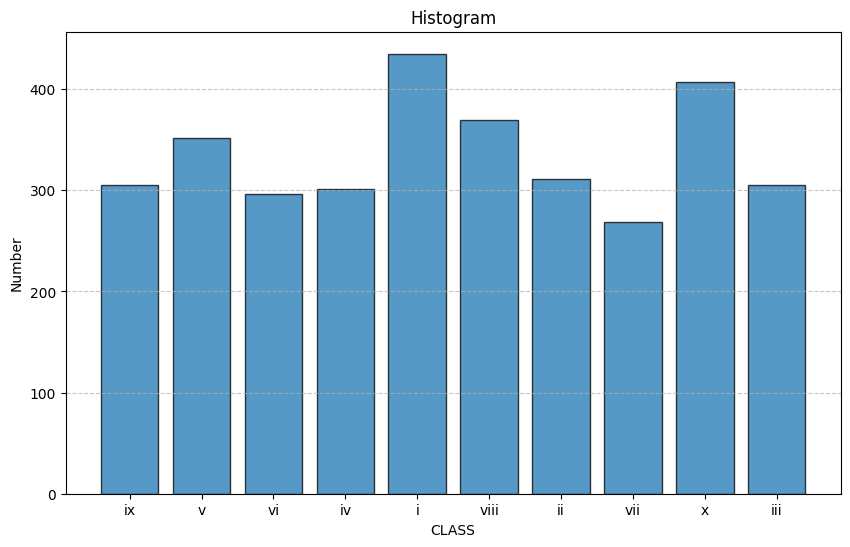

CLASS
ix: 305 筆
v: 352 筆
vi: 296 筆
iv: 301 筆
i: 435 筆
viii: 369 筆
ii: 311 筆
vii: 269 筆
x: 407 筆
iii: 305 筆


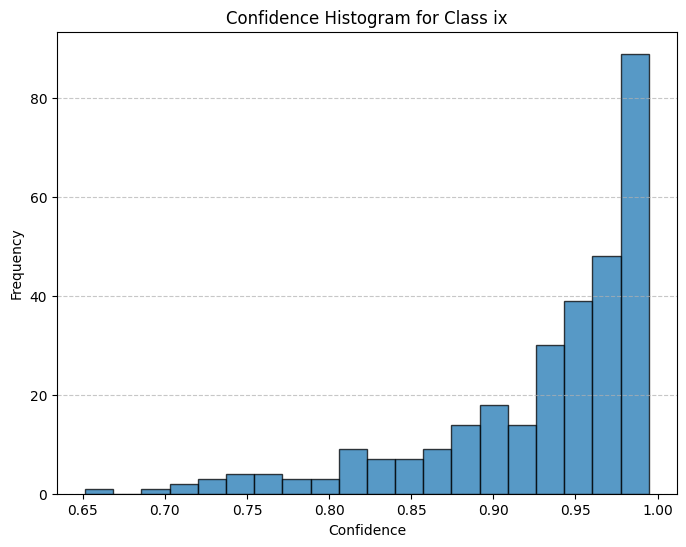

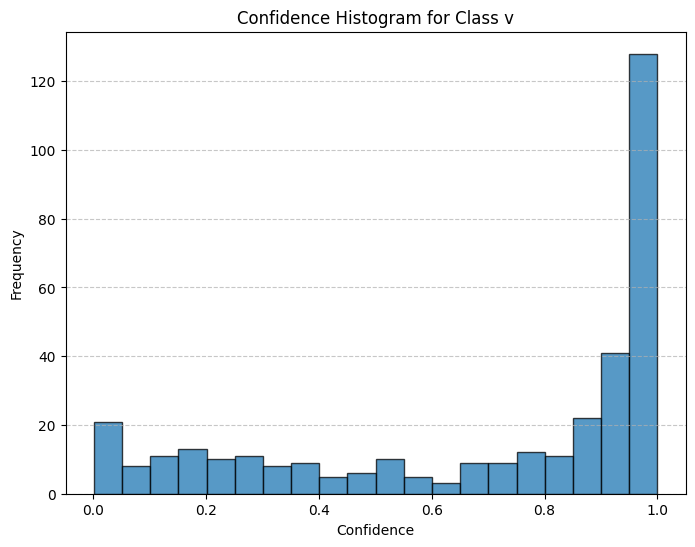

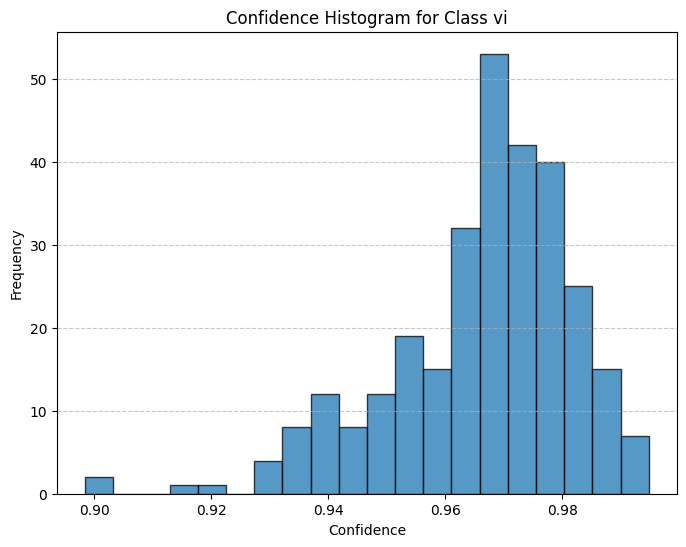

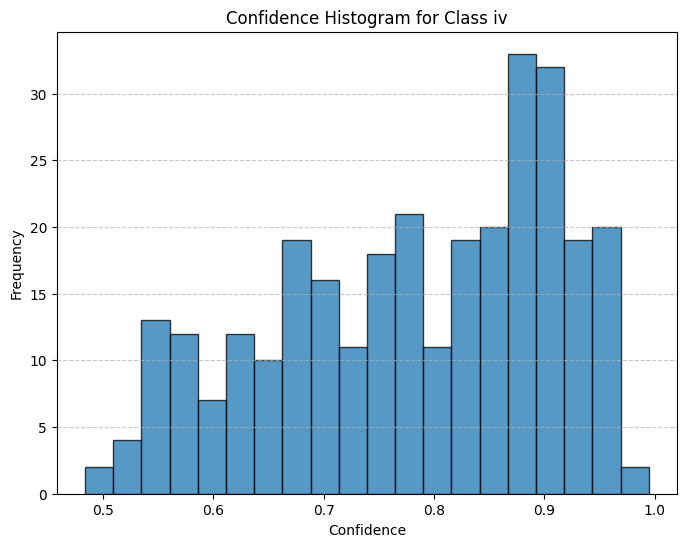

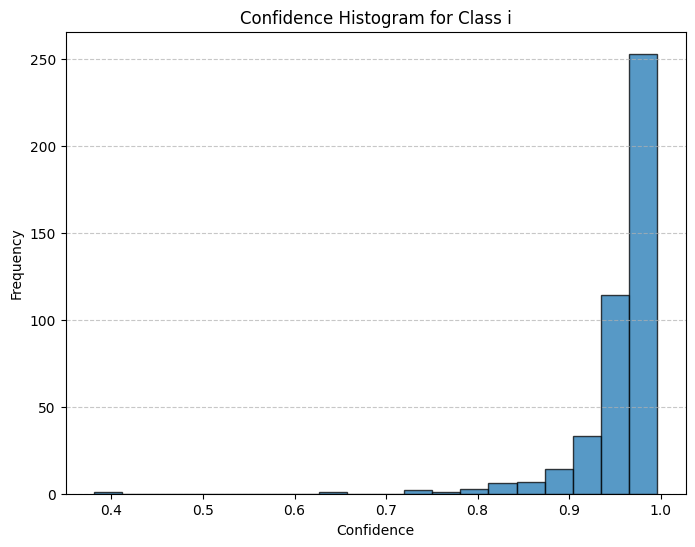

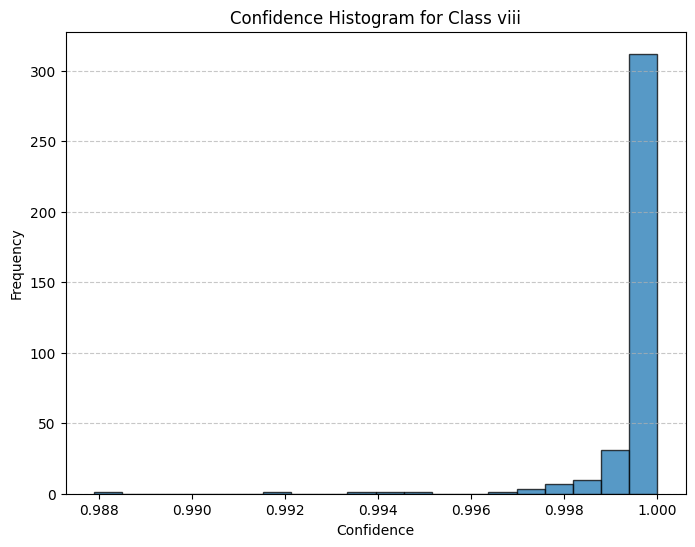

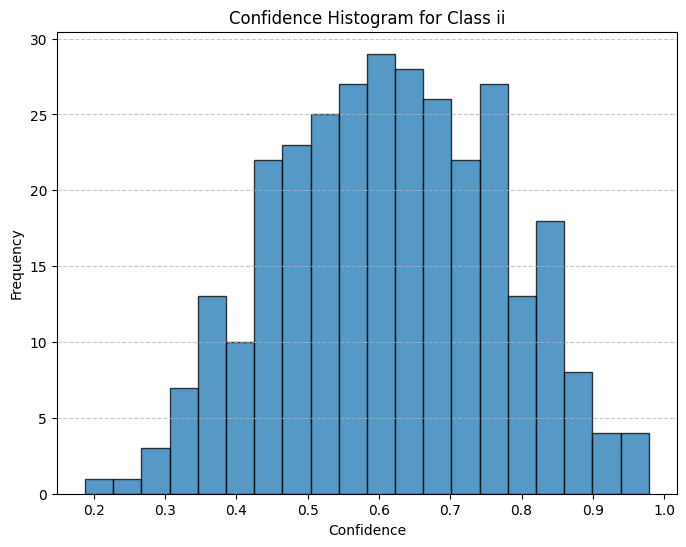

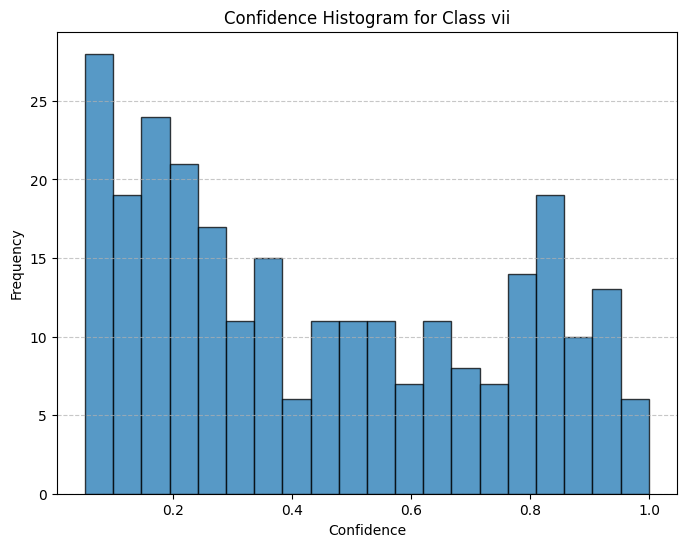

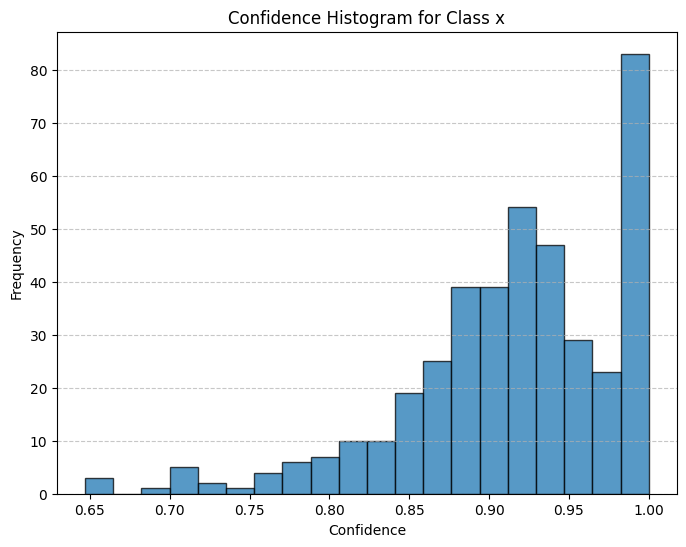

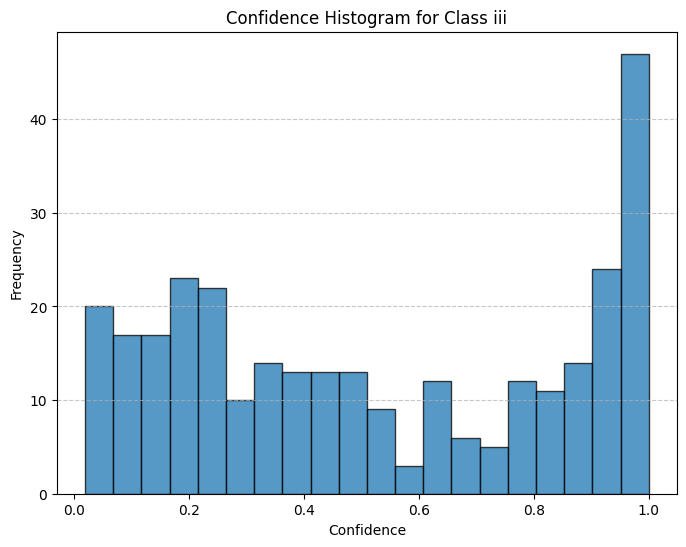

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 定義分類資料夾的根目錄
class_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class"

# 定義目標類別
target_classes = {'i', 'ii', 'iii', 'iv', 'ix', 'v', 'vi', 'vii', 'viii', 'x'}

# 初始化字典存儲每個類別的總資料筆數和 Confidence 資料
class_row_counts = {}
confidence_data = {}

# 計算每個類別的資料筆數並收集 Confidence 欄位
for target_class in target_classes:
    class_dir = os.path.join(class_root_dir, target_class)
    total_rows = 0
    confidences = []

    if os.path.exists(class_dir):
        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)
            if os.path.isfile(file_path) and file_path.endswith(".csv"):
                try:
                    # 讀取 CSV 檔案
                    df = pd.read_csv(file_path)
                    total_rows += len(df)  # 加入資料列數
                    if 'Confidence' in df.columns:
                        confidences.extend(df['Confidence'].dropna().tolist())
                except Exception as e:
                    print(f"無法讀取檔案: {file_path}, 錯誤: {e}")

    class_row_counts[target_class] = total_rows
    confidence_data[target_class] = confidences

# 繪製各類別的資料筆數質方圖
plt.figure(figsize=(10, 6))
plt.bar(class_row_counts.keys(), class_row_counts.values(), alpha=0.75, edgecolor='black')
plt.title("Histogram")
plt.xlabel("CLASS")
plt.ylabel("Number")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 顯示各類別的資料筆數
print("CLASS")
for target_class, row_count in class_row_counts.items():
    print(f"{target_class}: {row_count} 筆")

# 繪製每個類別的 Confidence 質方圖
for target_class, confidences in confidence_data.items():
    if confidences:  # 確保有資料可視覺化
        plt.figure(figsize=(8, 6))
        plt.hist(confidences, bins=20, alpha=0.75, edgecolor='black')
        plt.title(f"Confidence Histogram for Class {target_class}")
        plt.xlabel("Confidence")
        plt.ylabel("Frequency")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


# 標籤排序

In [39]:
import os
import pandas as pd

# 定義分類資料夾的根目錄
class_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class"

# 定義目標類別
target_classes = {'i', 'ii', 'iii', 'iv', 'ix', 'v', 'vi', 'vii', 'viii', 'x'}

# 處理每個類別資料夾中的 CSV 檔案
for target_class in target_classes:
    class_dir = os.path.join(class_root_dir, target_class)
    if os.path.exists(class_dir):
        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)
            if os.path.isfile(file_path) and file_path.endswith(".csv"):
                try:
                    # 讀取 CSV 檔案
                    df = pd.read_csv(file_path)

                    # 確保存在 Confidence 欄位
                    if 'Confidence' in df.columns:
                        # 按 Confidence 欄位排序
                        df = df.sort_values(by='Confidence', ascending=False).reset_index(drop=True)

                        # 計算分位數並新增 Rank 欄位
                        df['Rank'] = 5  # 預設為 5（90% 以上）
                        df.loc[df.index < len(df) * 0.9, 'Rank'] = 4  # 60%-90%
                        df.loc[df.index < len(df) * 0.6, 'Rank'] = 3  # 50%-60%
                        df.loc[df.index < len(df) * 0.5, 'Rank'] = 2  # 20%-50%
                        df.loc[df.index < len(df) * 0.2, 'Rank'] = 1  # 前 10%-20%

                        # 生成新檔案名稱
                        new_file_path = os.path.join(class_dir, f"ranked_{file_name}")

                        # 保存新的 CSV 檔案
                        df.to_csv(new_file_path, index=False)
                        print(f"已處理並保存新檔案: {new_file_path}")
                except Exception as e:
                    print(f"無法處理檔案: {file_path}, 錯誤: {e}")

print("所有檔案已處理完成。")


已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/ix/ranked_confidence_matrix_ix.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/v/ranked_confidence_matrix_v.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/vi/ranked_confidence_matrix_vi.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/iv/ranked_confidence_matrix_iv.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/i/ranked_confidence_matrix_i.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/viii/ranked_confidence_matrix_viii.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/ii/ranked_confidence_matrix_ii.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/vii/ranked_confidence_matrix_vii.csv
已處理並保存新檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/x/ranke

# 合併

In [41]:
import os
import pandas as pd

# 定義來源資料夾和目標合併檔案路徑
class_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class"
output_file_path = os.path.join(class_root_dir, "merged_ranked_data.csv")

# 初始化一個空的 DataFrame 用於存放合併後的資料
merged_df = pd.DataFrame()

# 遍歷所有類別資料夾
for target_class in os.listdir(class_root_dir):
    class_dir = os.path.join(class_root_dir, target_class)
    if os.path.isdir(class_dir):
        for file_name in os.listdir(class_dir):
            if file_name.startswith("ranked_") and file_name.endswith(".csv"):
                file_path = os.path.join(class_dir, file_name)
                try:
                    # 讀取 ranked CSV 檔案
                    df = pd.read_csv(file_path)

                    # 新增類別標籤
                    df['Class'] = target_class  # 將類別名稱加入欄位

                    # 新增標記欄位，若 id 中包含 '_ADD_'，則標記為 1，否則為 0
                    if 'id' in df.columns:
                        df['Flag'] = df['id'].apply(lambda x: 1 if '_ADD_' in str(x) else 0)
                    else:
                        df['Flag'] = 0  # 若無 id 欄位，設為 0

                    # 合併到主 DataFrame
                    merged_df = pd.concat([merged_df, df], ignore_index=True)
                except Exception as e:
                    print(f"無法讀取或合併檔案: {file_path}, 錯誤: {e}")

# 保存合併後的檔案
merged_df.to_csv(output_file_path, index=False)
print(f"所有 ranked 檔案已合併並保存至: {output_file_path}")


所有 ranked 檔案已合併並保存至: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/merged_ranked_data.csv


## 是否為外部資料

In [42]:
import os
import pandas as pd

# 定義來源資料夾和目標合併檔案路徑
class_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class"
merged_file_path = os.path.join(class_root_dir, "merged_ranked_data.csv")
output_file_flag_1 = os.path.join(class_root_dir, "flag_1_data.csv")
output_file_flag_0 = os.path.join(class_root_dir, "flag_0_data.csv")

# 確保合併的檔案存在
if os.path.exists(merged_file_path):
    try:
        # 讀取合併後的檔案
        merged_df = pd.read_csv(merged_file_path)

        # 分離資料：Flag = 1 和 Flag = 0
        flag_1_df = merged_df[merged_df['Flag'] == 1]
        flag_0_df = merged_df[merged_df['Flag'] == 0]

        # 保存分離的檔案
        flag_1_df.to_csv(output_file_flag_1, index=False)
        flag_0_df.to_csv(output_file_flag_0, index=False)

        print(f"Flag = 1 的資料已保存至: {output_file_flag_1}")
        print(f"Flag = 0 的資料已保存至: {output_file_flag_0}")
    except Exception as e:
        print(f"無法處理合併檔案，錯誤: {e}")
else:
    print(f"合併檔案不存在: {merged_file_path}")


Flag = 1 的資料已保存至: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/flag_1_data.csv
Flag = 0 的資料已保存至: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/flag_0_data.csv


# 資料提取

In [4]:
import os
import pandas as pd
import shutil

# 定義檔案路徑
csv_file_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/merged_ranked_data.csv"
image_source_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images"
image_target_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images"

# 確保目標資料夾根目錄存在
if not os.path.exists(image_target_root_dir):
    os.makedirs(image_target_root_dir)

# 讀取 CSV 檔案
try:
    data = pd.read_csv(csv_file_path)
    if 'id' not in data.columns or 'Rank' not in data.columns or 'Class' not in data.columns:
        raise ValueError("CSV 檔案缺少必要的 'id'、'Rank' 或 'Class' 欄位。")
except Exception as e:
    print(f"無法讀取或處理 CSV 檔案: {csv_file_path}, 錯誤: {e}")
    exit()

# 確保 Rank 和 Class 欄位為正確型別
data['Rank'] = data['Rank'].astype(int)
data['Class'] = data['Class'].astype(str)

# 記錄處理狀態
processed_count = 0
missing_count = 0

# 將圖片依 Rank 和 Class 分類
for index, row in data.iterrows():
    try:
        image_id = str(row['id']).strip()  # 確保 id 是字串並去除多餘空白
        rank = row['Rank']  # Rank 值
        class_label = row['Class'].strip()  # Class 值
        image_file_name = f"{image_id}.png"  # 假設圖片名稱與 id 對應

        # 檢查圖片檔名是否包含多餘的 .png
        if image_file_name.endswith(".png.png"):
            image_file_name = image_file_name.replace(".png.png", ".png")

        source_file = os.path.join(image_source_dir, image_file_name)

        # 定義目標資料夾
        rank_target_dir = os.path.join(image_target_root_dir, f"Rank_{rank}")
        class_target_dir = os.path.join(rank_target_dir, class_label)  # Rank 下的 Class 資料夾
        if not os.path.exists(class_target_dir):
            os.makedirs(class_target_dir)

        # 複製圖片至目標資料夾
        if os.path.exists(source_file):
            target_file = os.path.join(class_target_dir, image_file_name)
            shutil.copy2(source_file, target_file)
            processed_count += 1
            print(f"已成功分類並複製檔案: {source_file} 至 {target_file}")
        else:
            missing_count += 1
            print(f"圖片檔案不存在: {source_file}")
    except Exception as e:
        print(f"處理檔案時發生錯誤 (Index: {index}): {e}")

print(f"圖片分類處理完成，共處理成功: {processed_count} 筆，缺失圖片: {missing_count} 筆。")


已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_316.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_316.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_332.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_332.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_121.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_121.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_45.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_45.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_119.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_119.png
已成功分類並複製檔案: 

In [18]:
# import os
# import pandas as pd
# import shutil

# # 定義檔案路徑
# csv_file_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/Outcome/Class/merged_ranked_data.csv"
# image_source_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images"
# image_target_root_dir = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images"

# # 確保目標資料夾根目錄存在
# if not os.path.exists(image_target_root_dir):
#     os.makedirs(image_target_root_dir)

# # 讀取 CSV 檔案
# try:
#     data = pd.read_csv(csv_file_path)
#     if 'id' not in data.columns or 'Rank' not in data.columns or 'Class' not in data.columns:
#         raise ValueError("CSV 檔案缺少必要的 'id'、'Rank' 或 'Class' 欄位。")
# except Exception as e:
#     print(f"無法讀取或處理 CSV 檔案: {csv_file_path}, 錯誤: {e}")
#     exit()

# # 確保 Rank 和 Class 欄位為正確型別
# data['Rank'] = data['Rank'].astype(int)
# data['Class'] = data['Class'].astype(str)

# # 將圖片依 Rank 和 Class 分類
# for index, row in data.iterrows():
#     image_id = str(row['id'])  # 確保 id 是字串
#     rank = row['Rank']  # Rank 值
#     class_label = row['Class']  # Class 值
#     image_file_name = f"{image_id}.png"  # 假設圖片名稱與 id 對應

#     # 檢查圖片檔名是否包含多餘的 .png
#     if image_file_name.endswith(".png.png"):
#         image_file_name = image_file_name.replace(".png.png", ".png")

#     source_file = os.path.join(image_source_dir, image_file_name)

#     # 定義目標資料夾
#     rank_target_dir = os.path.join(image_target_root_dir, f"Rank_{rank}")
#     class_target_dir = os.path.join(rank_target_dir, class_label)  # Rank 下的 Class 資料夾
#     if not os.path.exists(class_target_dir):
#         os.makedirs(class_target_dir)

#     # 複製圖片至目標資料夾
#     if os.path.exists(source_file):
#         target_file = os.path.join(class_target_dir, image_file_name)
#         try:
#             shutil.copy2(source_file, target_file)
#             print(f"已成功分類並複製檔案: {source_file} 至 {target_file}")
#         except Exception as e:
#             print(f"無法複製檔案: {source_file}, 錯誤: {e}")
#     else:
#         print(f"圖片檔案不存在: {source_file}")

# print("圖片分類處理完成。")


已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_316.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_316.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_332.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_332.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_121.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_121.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_45.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_45.png
已成功分類並複製檔案: /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Copied_Images/ix_119.png 至 /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/ix/ix_119.png
已成功分類並複製檔案: 

# 圖片強化

In [14]:
# 訓練數據集路徑
Renk_1_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/"
Renk_2_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_2/"
Renk_3_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_3/"
Renk_4_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_4/"
Renk_5_path = "/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_5/"

# Renk_1(最優)

In [28]:

#####################################################################################################

Renk_1 = Renk_1_path

imagelab = Imagelab(data_path=Renk_1)
issues = imagelab.find_issues(verbose=False)

# imagelab.report(max_prevalence=1.00)

display(imagelab.issue_summary)
imagelab_df = imagelab.issues
display(imagelab_df)

#####################################################################################################


Reading images from /content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1


  0%|          | 0/674 [00:00<?, ?it/s]

  0%|          | 0/674 [00:00<?, ?it/s]

,issue_type,num_images
0,grayscale,674
1,low_information,182
2,light,168
3,odd_size,3
4,odd_aspect_ratio,1
5,dark,0
6,blurry,0
7,exact_duplicates,0
8,near_duplicates,0


,odd_size_score,is_odd_size_issue,odd_aspect_ratio_score,is_odd_aspect_ratio_issue,low_information_score,is_low_information_issue,light_score,is_light_issue,grayscale_score,is_grayscale_issue,dark_score,is_dark_issue,blurry_score,is_blurry_issue,exact_duplicates_score,is_exact_duplicates_issue,near_duplicates_score,is_near_duplicates_issue
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/i/i_152.png,0.907138,False,0.575646,False,0.010526,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/i/i_174.png,0.955443,False,0.980769,False,0.026425,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/i/i_18.png,0.957537,False,0.663102,False,0.024520,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/i/i_184.png,0.909795,False,0.915094,False,0.019094,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/i/i_199.png,0.957537,False,0.663102,False,0.023455,True,0.000000,True,0,True,1.000000,False,1.000000,False,1.0,False,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/x/x_ADD_442.png,0.971501,False,0.992754,False,0.466233,False,0.866667,False,0,True,0.737255,False,0.954509,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/x/x_ADD_443.png,0.958746,False,0.986842,False,0.529748,False,1.000000,False,0,True,0.686275,False,0.805844,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/x/x_ADD_444.png,0.988072,False,0.951220,False,0.434941,False,0.890196,False,0,True,0.784314,False,1.000000,False,1.0,False,1.0,False
/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/x/x_ADD_446.png,0.995895,False,0.980769,False,0.553724,False,0.701961,False,0,True,0.792157,False,0.792523,False,1.0,False,1.0,False


Found 674 files belonging to 10 classes.


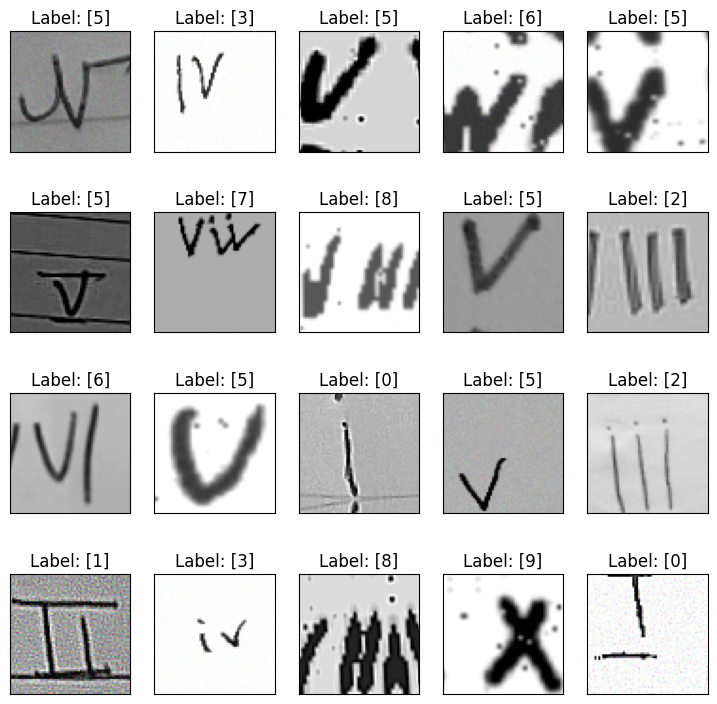

In [41]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import albumentations as A
from functools import partial
import matplotlib.pyplot as plt

# 定義 label 到資料夾名稱的對應關係
label_to_folder = {
    0: "i", 1: "ii", 2: "iii", 3: "iv", 4: "ix", 5: "v",
    6: "vi", 7: "vii", 8: "viii", 9: "x"
}


# 設定隨機種子碼
tf.keras.backend.clear_session()
SEED = 202
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

image_size = (64, 64)  # 定義為 (height, width) tuple
batch_size = 32

train_dataset = image_dataset_from_directory(
    Renk_1_path,
    image_size=image_size,
    shuffle=True,
    batch_size=1,
    seed=SEED
)

AUTOTUNE = tf.data.experimental.AUTOTUNE

# 數據增強函數
import albumentations as A

def augment_train_data_with_blur(train_ds):
    transforms = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.20, scale_limit=0.10, rotate_limit=5, p=1),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.5),  # 提高清晰度
        A.GaussianBlur(blur_limit=(11, 21), p=0.5)  # 模糊背景
    ])

    return transforms


    def aug_fn(image):
        # For OpenCV convention
        image = image.astype(np.uint8)
        data = {"image": image.squeeze()}
        # Passes the contents of the data dictionary as keyword arguments
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        # Back to keras
        aug_img = tf.cast(aug_img / 255.0, tf.float32)
        return aug_img

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label

    def set_shapes(img, label, img_shape=(64, 64, 3)):  # 修正這裡
        img.set_shape(img_shape)
        label.set_shape([1, ])
        return img, label

    ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(batch_size)  # Return to original batch size here
    return ds_alb

train_alb = augment_train_data(train_dataset)

# 視覺化增強後的圖像
def view_image(ds):
    image, label = next(iter(ds))  # 提取一批數據
    image = image.numpy()
    label = label.numpy()

    fig = plt.figure(figsize=(9, 9))
    for i in range(min(20, len(image))):  # 確保不超出批量大小
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image[i])
        ax.set_title(f"Label: {label[i]}")
    plt.show()

view_image(train_alb)


In [39]:
from PIL import Image
import os

# 保存增強後的圖像
def save_augmented_images(ds, save_dir="/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_1/Outcome/"):
    os.makedirs(save_dir, exist_ok=True)  # 創建目錄
    for batch_idx, (images, labels) in enumerate(ds):
        images = images.numpy()
        labels = labels.numpy().astype(int)
        for i, (image, label) in enumerate(zip(images, labels)):
            label_folder = label_to_folder.get(label[0], "unknown")
            output_folder = os.path.join(save_dir, label_folder)
            os.makedirs(output_folder, exist_ok=True)
            # 保存圖像
            image_path = os.path.join(output_folder, f"aug_image_{batch_idx}_{i}.png")
            image = (image * 255).astype(np.uint8)  # 恢復到 0-255 範圍
            Image.fromarray(image).save(image_path)

# 執行保存圖片
save_augmented_images(train_alb)


# Renk_2

Found 1005 files belonging to 10 classes.


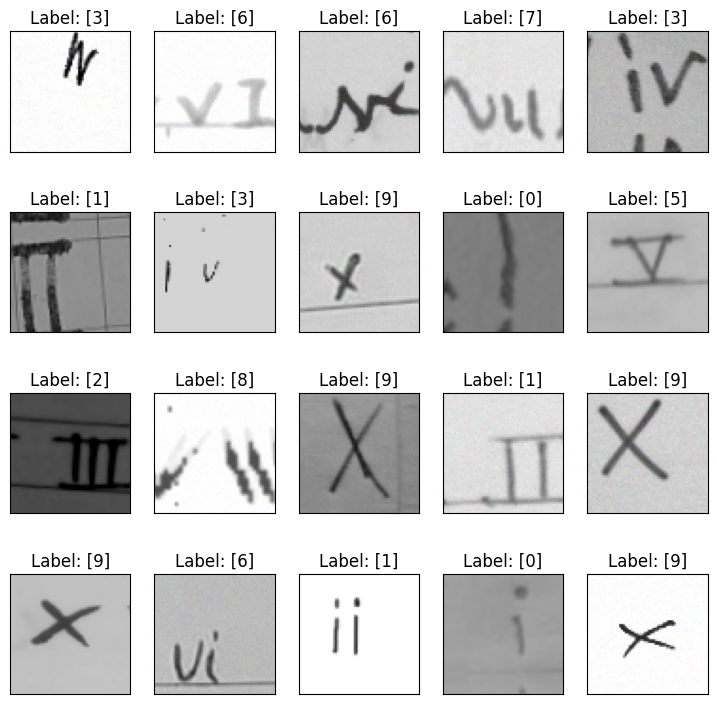

In [31]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import albumentations as A
from functools import partial
import matplotlib.pyplot as plt

# 定義 label 到資料夾名稱的對應關係
label_to_folder = {
    0: "i", 1: "ii", 2: "iii", 3: "iv", 4: "ix", 5: "v",
    6: "vi", 7: "vii", 8: "viii", 9: "x"
}


# 設定隨機種子碼
tf.keras.backend.clear_session()
SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

image_size = (64, 64)  # 定義為 (height, width) tuple
batch_size = 32

train_dataset = image_dataset_from_directory(
    Renk_2_path,
    image_size=image_size,
    shuffle=True,
    batch_size=1,
    seed=SEED
)

AUTOTUNE = tf.data.experimental.AUTOTUNE

# 數據增強函數
def augment_train_data(train_ds):
    transforms = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.20, scale_limit=0.10, rotate_limit=5, p=1),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ])

    def aug_fn(image):
        # For OpenCV convention
        image = image.astype(np.uint8)
        data = {"image": image.squeeze()}
        # Passes the contents of the data dictionary as keyword arguments
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        # Back to keras
        aug_img = tf.cast(aug_img / 255.0, tf.float32)
        return aug_img

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label

    def set_shapes(img, label, img_shape=(64, 64, 3)):  # 修正這裡
        img.set_shape(img_shape)
        label.set_shape([1, ])
        return img, label

    ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(batch_size)  # Return to original batch size here
    return ds_alb

train_alb = augment_train_data(train_dataset)

# 視覺化增強後的圖像
def view_image(ds):
    image, label = next(iter(ds))  # 提取一批數據
    image = image.numpy()
    label = label.numpy()

    fig = plt.figure(figsize=(9, 9))
    for i in range(min(20, len(image))):  # 確保不超出批量大小
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image[i])
        ax.set_title(f"Label: {label[i]}")
    plt.show()

view_image(train_alb)


In [32]:
from PIL import Image
import os

# 保存增強後的圖像
def save_augmented_images(ds, save_dir="/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_2/Outcome/"):
    os.makedirs(save_dir, exist_ok=True)  # 創建目錄
    for batch_idx, (images, labels) in enumerate(ds):
        images = images.numpy()
        labels = labels.numpy().astype(int)
        for i, (image, label) in enumerate(zip(images, labels)):
            label_folder = label_to_folder.get(label[0], "unknown")
            output_folder = os.path.join(save_dir, label_folder)
            os.makedirs(output_folder, exist_ok=True)
            # 保存圖像
            image_path = os.path.join(output_folder, f"aug_image_{batch_idx}_{i}.png")
            image = (image * 255).astype(np.uint8)  # 恢復到 0-255 範圍
            Image.fromarray(image).save(image_path)

# 執行保存圖片
save_augmented_images(train_alb)


# Renk_3

Found 335 files belonging to 10 classes.


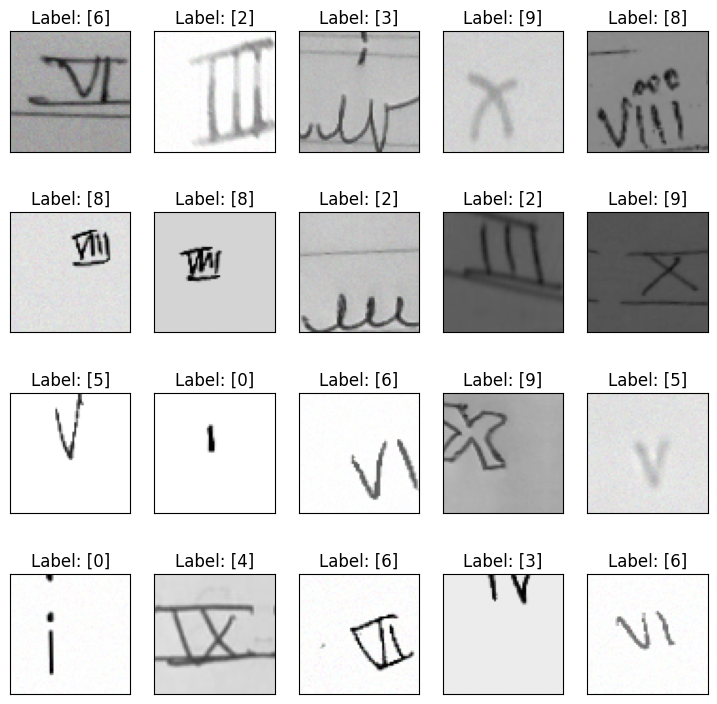

In [33]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import albumentations as A
from functools import partial
import matplotlib.pyplot as plt

# 定義 label 到資料夾名稱的對應關係
label_to_folder = {
    0: "i", 1: "ii", 2: "iii", 3: "iv", 4: "ix", 5: "v",
    6: "vi", 7: "vii", 8: "viii", 9: "x"
}


# 設定隨機種子碼
tf.keras.backend.clear_session()
SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

image_size = (64, 64)  # 定義為 (height, width) tuple
batch_size = 32

train_dataset = image_dataset_from_directory(
    Renk_3_path,
    image_size=image_size,
    shuffle=True,
    batch_size=1,
    seed=SEED
)

AUTOTUNE = tf.data.experimental.AUTOTUNE

# 數據增強函數
def augment_train_data(train_ds):
    transforms = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.20, scale_limit=0.10, rotate_limit=5, p=1),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ])

    def aug_fn(image):
        # For OpenCV convention
        image = image.astype(np.uint8)
        data = {"image": image.squeeze()}
        # Passes the contents of the data dictionary as keyword arguments
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        # Back to keras
        aug_img = tf.cast(aug_img / 255.0, tf.float32)
        return aug_img

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label

    def set_shapes(img, label, img_shape=(64, 64, 3)):  # 修正這裡
        img.set_shape(img_shape)
        label.set_shape([1, ])
        return img, label

    ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(batch_size)  # Return to original batch size here
    return ds_alb

train_alb = augment_train_data(train_dataset)

# 視覺化增強後的圖像
def view_image(ds):
    image, label = next(iter(ds))  # 提取一批數據
    image = image.numpy()
    label = label.numpy()

    fig = plt.figure(figsize=(9, 9))
    for i in range(min(20, len(image))):  # 確保不超出批量大小
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image[i])
        ax.set_title(f"Label: {label[i]}")
    plt.show()

view_image(train_alb)


In [34]:
from PIL import Image
import os

# 保存增強後的圖像
def save_augmented_images(ds, save_dir="/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_3/Outcome/"):
    os.makedirs(save_dir, exist_ok=True)  # 創建目錄
    for batch_idx, (images, labels) in enumerate(ds):
        images = images.numpy()
        labels = labels.numpy().astype(int)
        for i, (image, label) in enumerate(zip(images, labels)):
            label_folder = label_to_folder.get(label[0], "unknown")
            output_folder = os.path.join(save_dir, label_folder)
            os.makedirs(output_folder, exist_ok=True)
            # 保存圖像
            image_path = os.path.join(output_folder, f"aug_image_{batch_idx}_{i}.png")
            image = (image * 255).astype(np.uint8)  # 恢復到 0-255 範圍
            Image.fromarray(image).save(image_path)

# 執行保存圖片
save_augmented_images(train_alb)


# Renk_4

Found 1006 files belonging to 10 classes.


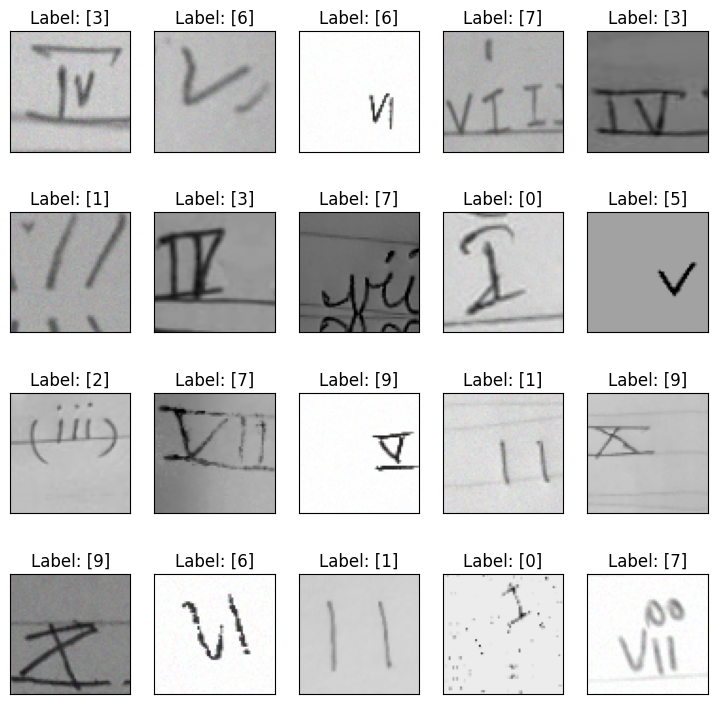

In [35]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import albumentations as A
from functools import partial
import matplotlib.pyplot as plt

# 定義 label 到資料夾名稱的對應關係
label_to_folder = {
    0: "i", 1: "ii", 2: "iii", 3: "iv", 4: "ix", 5: "v",
    6: "vi", 7: "vii", 8: "viii", 9: "x"
}


# 設定隨機種子碼
tf.keras.backend.clear_session()
SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

image_size = (64, 64)  # 定義為 (height, width) tuple
batch_size = 32

train_dataset = image_dataset_from_directory(
    Renk_4_path,
    image_size=image_size,
    shuffle=True,
    batch_size=1,
    seed=SEED
)

AUTOTUNE = tf.data.experimental.AUTOTUNE

# 數據增強函數
def augment_train_data(train_ds):
    transforms = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.20, scale_limit=0.10, rotate_limit=5, p=1),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    ])

    def aug_fn(image):
        # For OpenCV convention
        image = image.astype(np.uint8)
        data = {"image": image.squeeze()}
        # Passes the contents of the data dictionary as keyword arguments
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        # Back to keras
        aug_img = tf.cast(aug_img / 255.0, tf.float32)
        return aug_img

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label

    def set_shapes(img, label, img_shape=(64, 64, 3)):  # 修正這裡
        img.set_shape(img_shape)
        label.set_shape([1, ])
        return img, label

    ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(batch_size)  # Return to original batch size here
    return ds_alb

train_alb = augment_train_data(train_dataset)

# 視覺化增強後的圖像
def view_image(ds):
    image, label = next(iter(ds))  # 提取一批數據
    image = image.numpy()
    label = label.numpy()

    fig = plt.figure(figsize=(9, 9))
    for i in range(min(20, len(image))):  # 確保不超出批量大小
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image[i])
        ax.set_title(f"Label: {label[i]}")
    plt.show()

view_image(train_alb)


In [36]:
from PIL import Image
import os

# 保存增強後的圖像
def save_augmented_images(ds, save_dir="/content/drive/MyDrive/數據科學_期末/Roman Numerals Dataset/ORtrain/Ranked_Images/Rank_4/Outcome/"):
    os.makedirs(save_dir, exist_ok=True)  # 創建目錄
    for batch_idx, (images, labels) in enumerate(ds):
        images = images.numpy()
        labels = labels.numpy().astype(int)
        for i, (image, label) in enumerate(zip(images, labels)):
            label_folder = label_to_folder.get(label[0], "unknown")
            output_folder = os.path.join(save_dir, label_folder)
            os.makedirs(output_folder, exist_ok=True)
            # 保存圖像
            image_path = os.path.join(output_folder, f"aug_image_{batch_idx}_{i}.png")
            image = (image * 255).astype(np.uint8)  # 恢復到 0-255 範圍
            Image.fromarray(image).save(image_path)

# 執行保存圖片
save_augmented_images(train_alb)
